## What is the most optimal skill to learn for Data Analysts

#### Methology
1. Group skills to determine median salary and likelihood of beeing in posting
2. Visualize median salary vs percent skill demanded
3. (Optional) Determine if certain skill are more prevalent

In [53]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from matplotlib import cm
import ast
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [78]:
df_DA_Ger = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Germany')].copy()

In [79]:
df_DA_Ger = df_DA_Ger.dropna(subset='salary_year_avg')

df_DA_Ger_expl = df_DA_Ger.explode('job_skills')

df_DA_Ger_expl[['salary_year_avg', 'job_skills']].head()

,salary_year_avg,job_skills
20066,75067.5,r
20066,75067.5,python
20066,75067.5,java
20066,75067.5,c#
20066,75067.5,sql


In [80]:
df_skills = df_DA_Ger_expl.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_skills = df_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

job_count = len(df_DA_Ger)

df_skills['skill_percent'] = df_skills['skill_count'] / job_count * 100

df_skills



,skill_count,median_salary,skill_percent
job_skills,,,
sql,24,101500.00,50.000000
python,18,111175.00,37.500000
tableau,13,100500.00,27.083333
spark,7,111175.00,14.583333
r,7,75067.50,14.583333
excel,7,105650.00,14.583333
looker,5,53014.00,10.416667
power bi,4,83937.50,8.333333
go,4,52014.00,8.333333


In [81]:
skill_percentage = 5

df_skills_high_demand = df_skills[df_skills['skill_percent'] > skill_percentage]

df_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,24,101500.0,50.000000
python,18,111175.0,37.500000
tableau,13,100500.0,27.083333
spark,7,111175.0,14.583333
r,7,75067.5,14.583333
excel,7,105650.0,14.583333
looker,5,53014.0,10.416667
power bi,4,83937.5,8.333333
go,4,52014.0,8.333333


In [82]:
df_technology = df['job_type_skills'].copy()

df_technology = df_technology.drop_duplicates()

df_technology = df_technology.dropna()

technology_dict = {}

for row in df_technology:
    row_dict = ast.literal_eval(row)
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value
        else:
            technology_dict[key] = value

for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

In [83]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,ms access
0,analyst_tools,visio
0,analyst_tools,sas
0,analyst_tools,ssis
0,analyst_tools,ssrs
...,...,...
9,sync,rocketchat
9,sync,ringcentral
9,sync,microsoft teams
9,sync,mattermost


In [84]:
df_plot = df_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

df_plot = df_plot.set_index('skills')

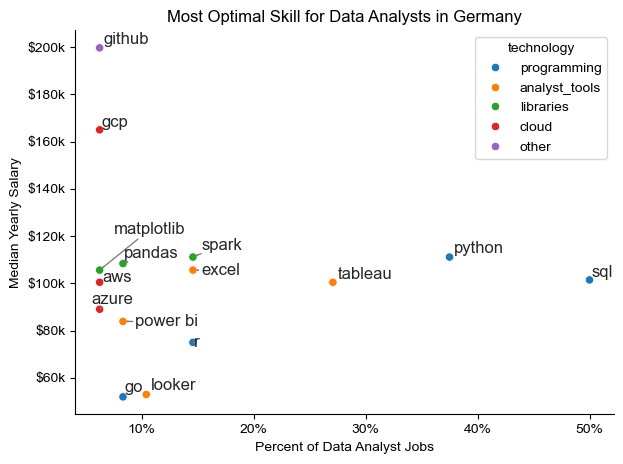

In [87]:
from adjustText import adjust_text

sns.scatterplot(
    data=df_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

texts = []
for i in range(len(df_plot)):
    texts.append(plt.text(
        df_plot['skill_percent'].iloc[i], 
        df_plot['median_salary'].iloc[i], 
        df_plot.index[i]  
    ))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))


from matplotlib.ticker import PercentFormatter
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
plt.gca().xaxis.set_major_formatter(PercentFormatter(decimals=0))


plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skill for Data Analysts in Germany')

plt.tight_layout()
plt.show()
